In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

Подготовка данных

In [7]:
# загружаем данные
iris = load_iris()

X = iris.data
y = iris.target

# оставляем только два класса (1 и 2)
mask = y != 0
X = X[mask]
y = y[mask]

# переводим классы в 0 и 1
y = (y == 2).astype(int)

# делим на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# масштабируем
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (80, 4)
Test: (20, 4)


Логистическая регрессия

In [8]:
class LogisticRegressionCustom:

    def __init__(self, lr=0.01, epochs=1000, optimizer="gd"):
        self.lr = lr
        self.epochs = epochs
        self.optimizer = optimizer


    # сигмоида — переводит число в вероятность
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))


    def fit(self, X, y):

        n_samples, n_features = X.shape

        # начинаем с нулевых весов
        self.w = np.zeros(n_features)

        # дополнительные переменные для адаптивных методов
        v = np.zeros(n_features)   # для RMSProp и Nadam
        m = np.zeros(n_features)   # только для Nadam

        beta1 = 0.9
        beta2 = 0.999
        eps = 1e-8

        self.losses = []


        for t in range(1, self.epochs + 1):

            # считаем предсказания
            z = np.dot(X, self.w)
            y_pred = self.sigmoid(z)

            # градиент (основная формула)
            grad = (1 / n_samples) * np.dot(X.T, (y_pred - y))


            # ---------- методы оптимизации ----------

            # обычный градиентный спуск
            if self.optimizer == "gd":
                self.w -= self.lr * grad


            # RMSProp — адаптивный шаг
            elif self.optimizer == "rmsprop":
                v = beta2 * v + (1 - beta2) * (grad ** 2)
                self.w -= self.lr * grad / (np.sqrt(v) + eps)


            # Nadam (упрощённая версия)
            elif self.optimizer == "nadam":

                # обновляем средний градиент
                m = beta1 * m + (1 - beta1) * grad

                # обновляем средний квадрат градиента
                v = beta2 * v + (1 - beta2) * (grad ** 2)

                # поправка на первые шаги
                m_corr = m / (1 - beta1 ** t)
                v_corr = v / (1 - beta2 ** t)

                # обновление весов
                self.w -= self.lr * m_corr / (np.sqrt(v_corr) + eps)


            # считаем функцию потерь
            loss = -np.mean(
                y * np.log(y_pred + eps) +
                (1 - y) * np.log(1 - y_pred + eps)
            )

            self.losses.append(loss)


    def predict(self, X):
        probs = self.sigmoid(np.dot(X, self.w))
        return (probs >= 0.5).astype(int)

Обучение и графики

Обучаем модель: gd


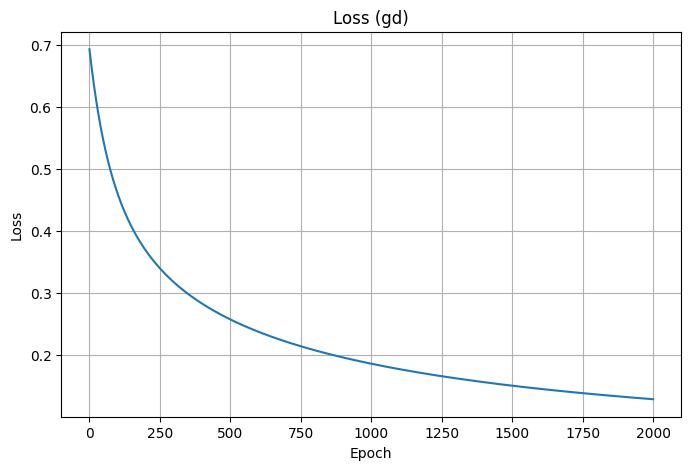

Обучаем модель: rmsprop


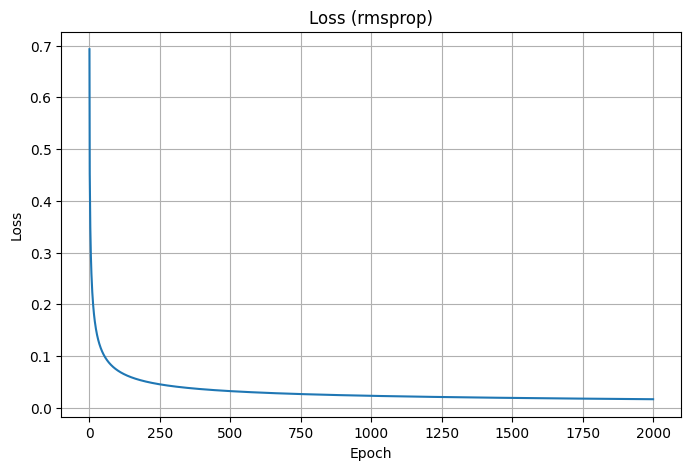

Обучаем модель: nadam


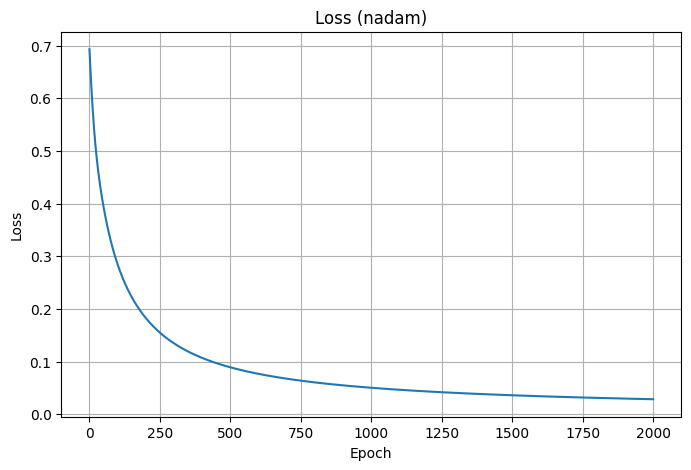

In [9]:
results = []

optimizers = ["gd", "rmsprop", "nadam"]

for opt in optimizers:

    print("Обучаем модель:", opt)

    model = LogisticRegressionCustom(
        lr=0.01,
        epochs=2000,
        optimizer=opt
    )

    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append([opt, acc, end - start])


    # строим график функции потерь
    plt.figure(figsize=(8,5))
    plt.plot(model.losses)
    plt.title(f"Loss ({opt})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

Результаты

In [10]:
results_df = pd.DataFrame(
    results,
    columns=["Метод", "Accuracy", "Время работы (сек)"]
)

results_df

,Метод,Accuracy,Время работы (сек)
0,gd,0.90,0.065512
1,rmsprop,0.90,0.079603
2,nadam,0.85,0.165891


Вывод

1. Обычный градиентный спуск работает, но сходится медленнее.
По графику видно, что loss уменьшается постепенно, но требуется больше итераций, чтобы достичь стабильности.
2. RMSProp ускоряет обучение за счёт адаптивного шага. Колебаний становится меньше. Сходимость становится более стабильной.
3. Nadam показывает стабильную и быструю сходимость. Т.е. более плавное движение к минимуму, меньше скачков, более быстрое достижение минимума.
4. Accuracy у всех методов высокая, так как классы хорошо разделимы.